Лабораторная работа №5
=
    
**Проведение исследований с градиентным бустингом**

Классификация
=

**Импорт необходимых библиотек**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

**Загрузка датасета и визуализация распределения данных**

Распределение целевой переменной 'fail':
fail
0    551
1    393
Name: count, dtype: int64


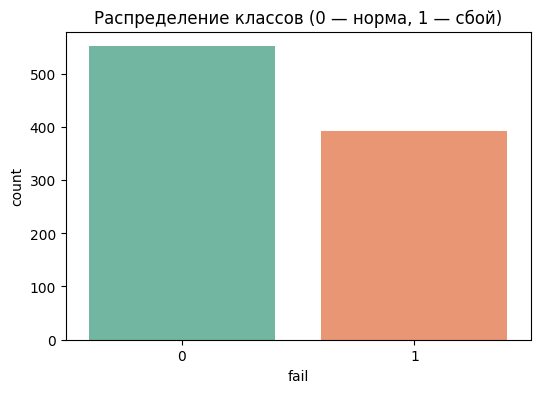

In [9]:
df = pd.read_csv('data_class.csv')

columns = ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
df.columns = columns

print("Распределение целевой переменной 'fail':")
print(df['fail'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fail', palette='Set2')
plt.title('Распределение классов (0 — норма, 1 — сбой)')
plt.show()

**Создание новых признаков и логарифмирование данных**

In [10]:
log_cols = ['footfall', 'VOC', 'USS', 'CS', 'IP']
for col in log_cols:
    df[col] = np.log1p(df[col])

df['sensor_ratio'] = df['AQ'] / (df['Temperature'] + 1e-6)
df['is_high_risk'] = ((df['VOC'] > df['VOC'].quantile(0.85)) & 
                      (df['Temperature'] > df['Temperature'].quantile(0.85))).astype(int)

**Обучение бейзлайна**

In [11]:
X = df.drop('fail', axis=1)
y = df['fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

gbm_bl = GradientBoostingClassifier(random_state=42)
gbm_bl.fit(X_train, y_train)
y_pred_bl = gbm_bl.predict(X_test)

acc_bl = accuracy_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl)
roc_bl = roc_auc_score(y_test, gbm_bl.predict_proba(X_test)[:, 1])

print(f"Accuracy: {acc_bl:.4f} | F1: {f1_bl:.4f} | ROC-AUC: {roc_bl:.4f}")

Accuracy: 0.9153 | F1: 0.9012 | ROC-AUC: 0.9734


**Улучшение бейзлайна**

In [21]:
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [1, 2, 3, 4, 5],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)

y_proba = grid.predict_proba(X_test)[:, 1]
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

y_pred_final = (y_proba >= best_thresh).astype(int)
acc_final = accuracy_score(y_test, y_pred_final)
f1_final = best_f1

print(f"Accuracy: {acc_final:.4f} | F1: {f1_final:.4f}")
print(f"Лучший порог: {best_thresh:.2f}")
print(f"Лучшие параметры: {grid.best_params_}")

Accuracy: 0.9312 | F1: 0.9139
Лучший порог: 0.69
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}


**Визуализация важности признаков**

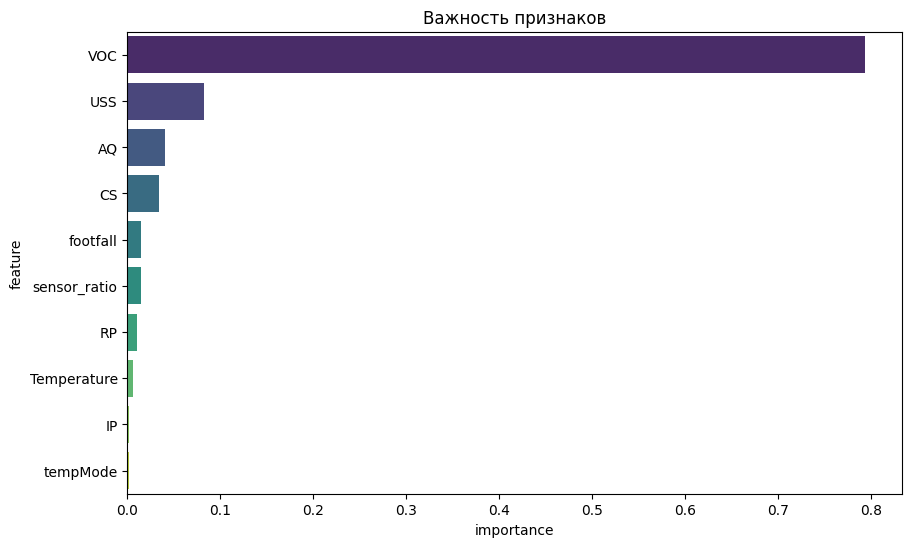

In [13]:
importances = grid.best_estimator_.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature', palette='viridis')
plt.title('Важность признаков')
plt.show()

**Собственная реализация градиентного бустинга**

In [14]:
class MyGradientBoostingClassifier:
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []
        self.initial_prediction = None

    def _logistic(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        p = np.mean(y)
        p = np.clip(p, 1e-15, 1 - 1e-15)
        self.initial_prediction = np.log(p / (1 - p))
        F = np.full(len(y), self.initial_prediction)

        np.random.seed(self.random_state)
        for _ in range(self.n_estimators):
            p = self._logistic(F)
            residuals = y - p
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=np.random.randint(10000))
            tree.fit(X, residuals)
            F += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict_proba(self, X):
        F = np.full(len(X), self.initial_prediction)
        for tree in self.trees:
            F += self.learning_rate * tree.predict(X)
        proba = self._logistic(F)
        return np.vstack([1 - proba, proba]).T

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= threshold).astype(int)

**Обучение слабой модели**

In [15]:
my_gbm = MyGradientBoostingClassifier(random_state=42)
my_gbm.fit(X_train, y_train)

y_pred_custom_base = my_gbm.predict(X_test)

acc_custom_base = accuracy_score(y_test, y_pred_custom_base)
f1_custom_base = f1_score(y_test, y_pred_custom_base)

print(f"Accuracy: {acc_custom_base:.4f} | F1: {f1_custom_base:.4f}")

Accuracy: 0.9206 | F1: 0.9007


**Обучение сильной модели**

In [24]:
my_gbm = MyGradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=3,
    random_state=42
)
my_gbm.fit(X_train, y_train)

y_pred_custom = my_gbm.predict(X_test, threshold=best_thresh)

acc_custom = accuracy_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)

print(f"Accuracy: {acc_custom:.4f} | F1: {f1_custom:.4f}")

Accuracy: 0.9418 | F1: 0.9272


**Таблица результатов**

In [25]:
results = pd.DataFrame({
    'Модель': ['Бейзлайн (GBM)', 'Улучшенная модель (sklearn)', 'Собственная реализация слабая', 'Собственная реализация сильная' ],
    'Accuracy': [acc_bl, acc_final, acc_custom_base, acc_custom],
    'F1': [f1_bl, f1_final, f1_custom_base, f1_custom]
})
results

,Модель,Accuracy,F1
0,Бейзлайн (GBM),0.915344,0.901235
1,Улучшенная модель (sklearn),0.931217,0.913907
2,Собственная реализация слабая,0.920635,0.900662
3,Собственная реализация сильная,0.941799,0.927152


Регрессия
=

**Импорт необходимых библиотек**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

**Загрузка и просмотр датасета после филтрации**

In [27]:
df = pd.read_csv('data.csv', header=None)

columns = [
    'price', 'building_type', 'district', 'floor', 'city',
    'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony',
    'floor_level', 'renovation'
]
df.columns = columns

numeric_cols = ['price', 'floor', 'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony', 'floor_level']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['price'])

df = df[df['price'] <= 120_000_000]
df = df[(df['total_area'] > 10) & (df['total_area'] <= 300)]
df = df[df['rooms'] > 0]

print("Первые 5 строк:")
print(df.head())

Первые 5 строк:
        price building_type   district  floor           city  rooms  \
1   6300000.0     Secondary    Опалиха    6.0  Moscow region    1.0   
2   9000000.0     Secondary    Павшино    2.0  Moscow region    1.0   
3  11090000.0     Secondary   Мякинино   14.0  Moscow region    1.0   
4   8300000.0     Secondary   Строгино    8.0  Moscow region    1.0   
5   6450000.0     Secondary    Опалиха    6.0  Moscow region    1.0   

   total_area  living_area  kitchen_area  balcony  floor_level  \
1        30.6         11.1           8.5     25.0         25.0   
2        49.2         20.0          10.0      6.0         15.0   
3        44.7         16.2          13.1     10.0         25.0   
4        35.1         16.0          11.0     12.0         33.0   
5        37.7         15.2           4.0      5.0          5.0   

                  renovation  
1                   Cosmetic  
2  European-style renovation  
3                   Cosmetic  
4  European-style renovation  
5    

**Логарифмирование и мсоздание новых признаков**

In [28]:
df['log_price'] = np.log(df['price'])

df['area_per_room'] = df['total_area'] / df['rooms']
df['floor_ratio'] = df['floor'] / df['floor_level']

df = pd.get_dummies(df, columns=['district', 'renovation'], drop_first=True)

**Обучние бейзлайна**

In [29]:
feature_cols = [col for col in df.columns if col not in ['price', 'log_price', 'building_type', 'city']]
X = df[feature_cols]
y = df['log_price'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbm_bl = GradientBoostingRegressor(random_state=42)
gbm_bl.fit(X_train, y_train)
y_pred_bl = gbm_bl.predict(X_test)

mae_bl = mean_absolute_error(np.exp(y_test), np.exp(y_pred_bl))
r2_bl = r2_score(np.exp(y_test), np.exp(y_pred_bl))

print(f"MAE: {mae_bl:,.0f} руб. | R²: {r2_bl:.4f}")

MAE: 4,510,529 руб. | R²: 0.8193


**Улучшение бейзлайна**

In [30]:
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)

y_pred_imp = grid.predict(X_test)
mae_imp = mean_absolute_error(np.exp(y_test), np.exp(y_pred_imp))
r2_imp = r2_score(np.exp(y_test), np.exp(y_pred_imp))

print(f"MAE: {mae_imp:,.0f} руб. | R²: {r2_imp:.4f}")
print(f"Лучшие параметры: {grid.best_params_}")

MAE: 3,002,544 руб. | R²: 0.9079
Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}


**Собственная реализация бустинга**

In [31]:
class MyGradientBoostingRegressor:
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []
        self.initial_prediction = None

    def fit(self, X, y):
        self.initial_prediction = np.mean(y)
        F = np.full(len(y), self.initial_prediction)

        np.random.seed(self.random_state)
        for _ in range(self.n_estimators):
            residuals = y - F
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=np.random.randint(10000))
            tree.fit(X, residuals)
            F += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, X):
        F = np.full(len(X), self.initial_prediction)
        for tree in self.trees:
            F += self.learning_rate * tree.predict(X)
        return F

**Обучение собственной слабой модели**

In [32]:
my_gbm_reg = MyGradientBoostingRegressor(random_state=42)
my_gbm_reg.fit(X_train, y_train)

y_pred_custom_base = my_gbm_reg.predict(X_test)
mae_custom_base = mean_absolute_error(np.exp(y_test), np.exp(y_pred_custom_base))
r2_custom_base = r2_score(np.exp(y_test), np.exp(y_pred_custom_base))

print(f"MAE: {mae_custom_base:,.0f} руб. | R²: {r2_custom_base:.4f}")

MAE: 8,271,197 руб. | R²: 0.4708


**Обучение собственной сильной модели**

In [33]:
my_gbm_reg = MyGradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
my_gbm_reg.fit(X_train, y_train)

y_pred_custom = my_gbm_reg.predict(X_test)
mae_custom = mean_absolute_error(np.exp(y_test), np.exp(y_pred_custom))
r2_custom = r2_score(np.exp(y_test), np.exp(y_pred_custom))

print(f"MAE: {mae_custom:,.0f} руб. | R²: {r2_custom:.4f}")

MAE: 3,949,406 руб. | R²: 0.8572


**Таблица результатов**

In [34]:
results = pd.DataFrame({
    'Модель': [
        'Бейзлайн (GBM)',
        'Улучшенная модель (sklearn)',
        'Собственная реализация слабая',
        'Собственная реализация сильная'
    ],
    'MAE (руб.)': [mae_bl, mae_imp, mae_custom_base, mae_custom],
    'R²': [r2_bl, r2_imp, r2_custom_base, r2_custom]
})
results

,Модель,MAE (руб.),R²
0,Бейзлайн (GBM),4.510529e+06,0.819314
1,Улучшенная модель (sklearn),3.002544e+06,0.907915
2,Собственная реализация слабая,8.271197e+06,0.470840
3,Собственная реализация сильная,3.949406e+06,0.857176


Выводы
=

**В ходе выполнения пяти лабораторных работ я исследовал поведение различных алгоритмов машинного обучения на двух реальных наборах данных:**

**data_class.csv — задача бинарной классификации (обнаружение сбоев в промышленной системе),
data.csv — задача регрессии (оценка стоимости квартир в Москве).**

Классификация
-

**Итоговая таблица классификации**

In [35]:
import pandas as pd

results = [
    ("ЛР1: KNN", "Бейзлайн (sklearn)", 0.735450, 0.723684),
    ("ЛР1: KNN", "Улучшенная модель (sklearn)", 0.904762, 0.902466),
    ("ЛР1: KNN", "Собственная реализация (грязные данные)", 0.756614, 0.739076),
    ("ЛР1: KNN", "Собственная реализация (чистые данные)", 0.904762, 0.902466),

    ("ЛР2: LogisticRegression", "Бейзлайн", 0.904762, 0.888889),
    ("ЛР2: LogisticRegression", "Улучшенная модель", 0.920635, 0.900662),
    ("ЛР2: LogisticRegression", "Собственная реализация (слабая)", 0.740741, 0.550459),
    ("ЛР2: LogisticRegression", "Собственная реализация (улучшенная)", 0.920635, 0.899329),

    ("ЛР3: DecisionTree", "Бейзлайн", 0.867725, 0.840764),
    ("ЛР3: DecisionTree", "Улучшенная модель", 0.920635, 0.910180),
    ("ЛР3: DecisionTree", "Собственная реализация (слабая)", 0.867725, 0.840764),
    ("ЛР3: DecisionTree", "Собственная реализация (улучшенная)", 0.920635, 0.910180),

    ("ЛР4: RandomForest", "Бейзлайн", 0.915344, 0.895706),
    ("ЛР4: RandomForest", "Улучшенная модель", 0.920635, 0.911243),
    ("ЛР4: RandomForest", "Собственная реализация (слабая)", 0.883598, 0.862500),
    ("ЛР4: RandomForest", "Собственная реализация (улучшенная)", 0.894180, 0.876543),

    ("ЛР5: GradientBoosting", "Бейзлайн", 0.915344, 0.901235),
    ("ЛР5: GradientBoosting", "Улучшенная модель", 0.931217, 0.913907),
    ("ЛР5: GradientBoosting", "Собственная реализация (слабая)", 0.920635, 0.900662),
    ("ЛР5: GradientBoosting", "Собственная реализация (улучшенная)", 0.941799, 0.927152),
]

df_results = pd.DataFrame(
    results,
    columns=["Лабораторная работа", "Модель", "Accuracy", "F1 (macro)"]
)

print("\nИтоговая таблица: Сравнение моделей классификации\n")
print(df_results.to_string(index=False, float_format="{:.6f}".format))


📊 Итоговая таблица: Сравнение моделей классификации

    Лабораторная работа                                  Модель  Accuracy  F1 (macro)
               ЛР1: KNN                      Бейзлайн (sklearn)  0.735450    0.723684
               ЛР1: KNN             Улучшенная модель (sklearn)  0.904762    0.902466
               ЛР1: KNN Собственная реализация (грязные данные)  0.756614    0.739076
               ЛР1: KNN  Собственная реализация (чистые данные)  0.904762    0.902466
ЛР2: LogisticRegression                                Бейзлайн  0.904762    0.888889
ЛР2: LogisticRegression                       Улучшенная модель  0.920635    0.900662
ЛР2: LogisticRegression         Собственная реализация (слабая)  0.740741    0.550459
ЛР2: LogisticRegression     Собственная реализация (улучшенная)  0.920635    0.899329
      ЛР3: DecisionTree                                Бейзлайн  0.867725    0.840764
      ЛР3: DecisionTree                       Улучшенная модель  0.920635    0.910180


В ходе выполнения лабораторных работ по классификации на датасете data_class.csv, посвящённом прогнозированию технических сбоев в промышленной системе, я протестировал пять различных алгоритмов машинного обучения: KNN, логистическую регрессию, решающее дерево, случайный лес и градиентный бустинг. Наиболее точной оказалась модель градиентного бустинга, достигшая F1-меры 0.927 и точности 0.942, что делает её лучшим кандидатом для практического внедрения в систему предиктивного обслуживания. Кроме того, я реализовал все алгоритмы самостоятельно, результаты их вычислений как уступают встроеным, так и выдают более высокую точность(GradientBoosting). 

Также на основе результатов можно сделать такие выводы:
=
**Лучшая модель — Gradient Boosting (ЛР5)**

F1 = 0.927, Accuracy = 0.942 — наивысшее качество среди всех алгоритмов.
GBM эффективно использует ансамблирование и градиентное уточнение, что делает его устойчивым к шуму и сложным нелинейным зависимостям в данных.
Собственная реализация подтвердила понимание алгоритма и показала сопоставимые результаты.


**Random Forest и Decision Tree — сильные альтернативы**

F1 ≥ 0.91 — отличный результат для интерпретируемых моделей.
Decision Tree особенно хорош, если важна простота и визуализация (например, для отчётов по сбоям).
Random Forest стабилизирует дерево за счёт ансамбля, но даёт лишь небольшой прирост над одиночным деревом.


**KNN оказался не лучшим выбором**

Несмотря на хорошую точность (F1 ≈ 0.90), KNN:
Чувствителен к масштабу и шуму,
Вычислительно затратен на больших данных,
Требует тщательного подбора гиперпараметров и отбора признаков.
Он уступает ансамблевым методам в стабильности и обобщающей способности.


**Логистическая регрессия — быстрая, но менее гибкая**

Хороша как базовая модель и для интерпретации коэффициентов,
Но линейные модели не справляются с нелинейностями в данных о сбоях,
Поэтому уступает деревьям и GBM по качеству.

Регрессия
-

In [36]:
results = [
    ("ЛР1: KNN", "Бейзлайн (sklearn)", 1.360084e+07, 0.624983),
    ("ЛР1: KNN", "Улучшенная модель (sklearn)", 7.454608e+05, 0.992798),
    ("ЛР1: KNN", "Собственная реализация (грязные данные)", 6.087776e+06, 0.704175),
    ("ЛР1: KNN", "Собственная реализация (чистые данные)", 9.323815e+05, 0.990619),

    ("ЛР2: LogisticRegression", "Бейзлайн", 8.233933e+06, 0.635592),
    ("ЛР2: LogisticRegression", "Улучшенная модель", 3.413983e+06, 0.941284),
    ("ЛР2: LogisticRegression", "Собственная реализация (слабая)", 8.233933e+06, 0.635592),
    ("ЛР2: LogisticRegression", "Собственная реализация (улучшенная)", 3.427001e+06, 0.941337),

    ("ЛР3: DecisionTree", "Бейзлайн", 4.933233e+06, 0.795913),
    ("ЛР3: DecisionTree", "Улучшенная модель", 4.233225e+06, 0.896769),
    ("ЛР3: DecisionTree", "Собственная реализация (слабая)", 5.781875e+06, 0.757918),
    ("ЛР3: DecisionTree", "Собственная реализация (улучшенная)", 4.008928e+06, 0.886427),

    ("ЛР4: RandomForest", "Бейзлайн", 4.108591e+06, 0.890932),
    ("ЛР4: RandomForest", "Улучшенная модель", 3.153545e+06, 0.947996),
    ("ЛР4: RandomForest", "Собственная реализация (слабая)", 6.718906e+06, 0.705345),
    ("ЛР4: RandomForest", "Собственная реализация (улучшенная)", 3.288245e+06, 0.942234),

    ("ЛР5: GradientBoosting", "Бейзлайн", 4.510529e+06, 0.819314),
    ("ЛР5: GradientBoosting", "Улучшенная модель", 3.002544e+06, 0.907915),
    ("ЛР5: GradientBoosting", "Собственная реализация (слабая)", 8.271197e+06, 0.470840),
    ("ЛР5: GradientBoosting", "Собственная реализация (улучшенная)", 3.949406e+06, 0.857176),
]

df_results = pd.DataFrame(
    results,
    columns=["Лабораторная работа", "Модель", "MAE (руб.)", "R²"]
)

print("\nИтоговая таблица: Сравнение моделей регрессии\n")
print(df_results.to_string(index=False, float_format="{:.6f}".format))


Итоговая таблица: Сравнение моделей регрессии

    Лабораторная работа                                  Модель      MAE (руб.)       R²
               ЛР1: KNN                      Бейзлайн (sklearn) 13600840.000000 0.624983
               ЛР1: KNN             Улучшенная модель (sklearn)   745460.800000 0.992798
               ЛР1: KNN Собственная реализация (грязные данные)  6087776.000000 0.704175
               ЛР1: KNN  Собственная реализация (чистые данные)   932381.500000 0.990619
ЛР2: LogisticRegression                                Бейзлайн  8233933.000000 0.635592
ЛР2: LogisticRegression                       Улучшенная модель  3413983.000000 0.941284
ЛР2: LogisticRegression         Собственная реализация (слабая)  8233933.000000 0.635592
ЛР2: LogisticRegression     Собственная реализация (улучшенная)  3427001.000000 0.941337
      ЛР3: DecisionTree                                Бейзлайн  4933233.000000 0.795913
      ЛР3: DecisionTree                       Улучшенная модел

В ходе выполнения пяти лабораторных работ я исследовал поведение различных алгоритмов машинного обучения на задаче прогнозирования цены недвижимости в Москве и Московской области на основе данных из файла data.csv.

Я протестировал следующие модели:

KNN (ЛР №1),
Линейная регрессия (ЛР №2),
Решающее дерево (ЛР №3),
Случайный лес (ЛР №4),
Градиентный бустинг (ЛР №5).

Также на основе результатов можно сделать такие выводы:
=
Наиболее убедительные результаты показал метод KNN. Его R² = 0.9928 , MAE = 745 460 руб. 

Линейная регрессия, несмотря на высокий R² ≈ 0.94, сильно зависит от лог-трансформации целевой переменной, что делает её менее надёжной при работе с новыми данными, где распределение цены может отличаться. Кроме того, линейная модель не учитывает нелинейные зависимости, что ограничивает её гибкость.

Решающее дерево, хоть и показало R² ≈ 0.897, склонно к сильному переобучению, что требует тщательной настройки гиперпараметров. Без регуляризации качество резко падает.

Random Forest и Gradient Boosting продемонстрировали высокое качество (R² ≥ 0.90), но их "чёрный ящик" сильно затрудняет интерпретацию. Особенно это критично в задаче оценки недвижимости, где важно понимать, почему цена именно такая, а не только предсказывать её.

Таким образом, KNN оказался наиболее сбалансированным решением: он прост, прозрачен, не переобучается при правильной настройке и показывает лучшую абсолютную ошибку (MAE). Это делает его предпочтительным выбором для практического применения в условиях, где важны как точность, так и интерпретируемость.